In [14]:
#Imports numpy for math, matplotlib for plotting, and Bloch from qutip for the Bloch sphere visualization.
import numpy as np
import matplotlib.pyplot as plt
from qutip import Bloch

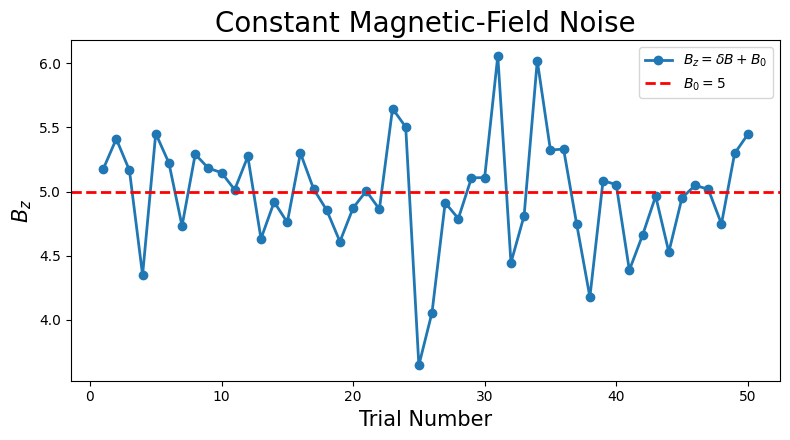

In [15]:
#Defines the main variables: constant average magnetic field, noise strength, number of random trials, and random seed.
B0 = 5.0
sigma = 0.5
numTrials = 50
seed = 1

#Generates a different constant Bz for each trial from a normal distribution centered at B0.
#Clear example of noise in a magnetic field.
rng = np.random.default_rng(seed)
trialList = np.arange(1, numTrials+1)
BzValues = rng.normal(B0, sigma, numTrials)

#Plots magnetic field for each random trial.
plt.figure(figsize=(8, 4.5))
plt.plot(trialList, BzValues, linewidth=2, marker="o", label="$B_z=δB+B_0$")

#Shows constant B0 of the magnetic field to compare how Bz strays from it.
plt.axhline(B0, color="red", linestyle="--", linewidth=2, label=r"$B_0=5$")

plt.title("Constant Magnetic-Field Noise", fontsize=20)
plt.xlabel("Trial Number", fontsize=15)
plt.ylabel(r"$B_z$", fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

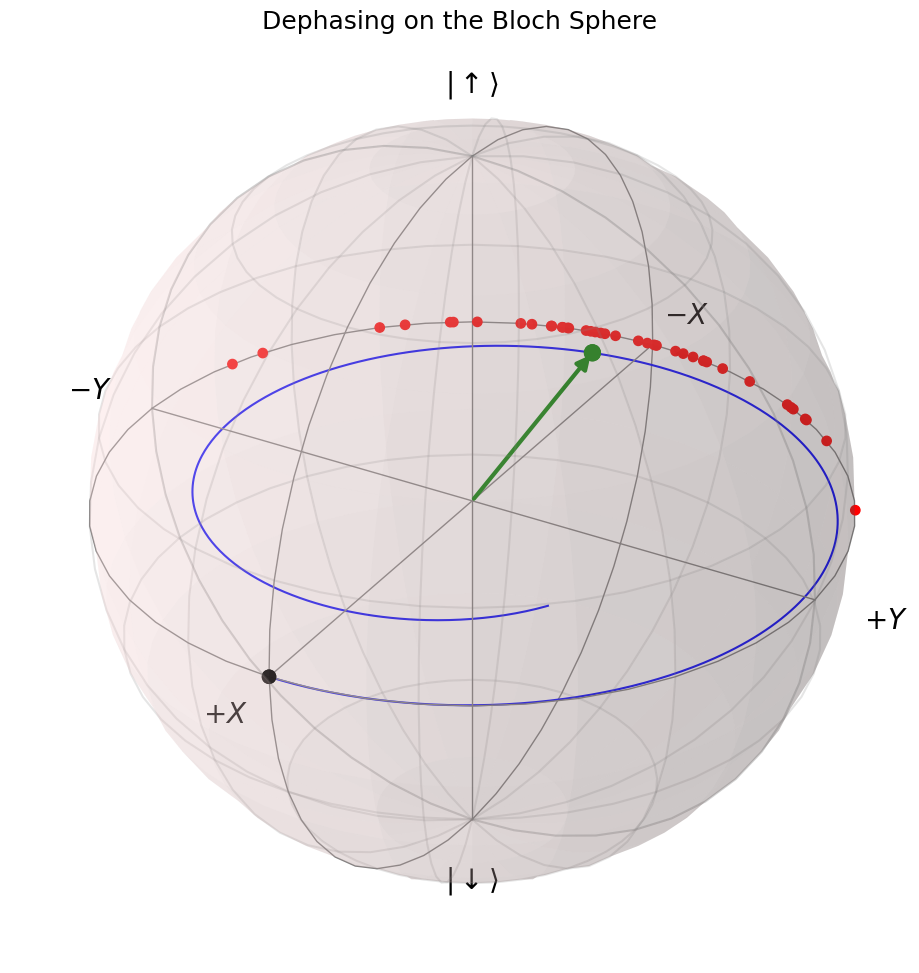

In [16]:
#Defines all the parameters for the visualizations.
B0 = 3.0
sigma = 0.5
tmax = 1.2
deltat = 0.002
numTrials = 500
selectedTime = 0.55
numDisplayedPoints = 40
seed = 1

#Creates time grid and assigns each trial a constant noisy magnetic field value.
rng = np.random.default_rng(seed)
timeList = np.arange(0.0, tmax+deltat, deltat)
BValues = rng.normal(B0, sigma, numTrials)

#Calculates phase accumulation by each spin at each time.
phaseData = 2.0*BValues[:, None]*timeList[None, :]

#Converts the phase of every spin into X and Y coordinates on the Bloch sphere.
xData = np.cos(phaseData)
yData = np.sin(phaseData)

#Calculates the average Bloch vector as the spins dephase.
averageX = np.mean(xData, axis=0)
averageY = np.mean(yData, axis=0)
averageZ = np.zeros_like(timeList)

#Finds the time point used to show individual spin directions and randomly selects the trials to show.
selectedIndex = np.argmin(np.abs(timeList-selectedTime))
displayedIndices = rng.choice(numTrials, size=numDisplayedPoints, replace=False)

#Gets the coordinates of the Bloch sphere of the selected individual spins at the time.
individualX = xData[displayedIndices, selectedIndex]
individualY = yData[displayedIndices, selectedIndex]
individualZ = np.zeros(numDisplayedPoints)

#Gets the average Bloch vector at the chosen time.
selectedAverageX = averageX[selectedIndex]
selectedAverageY = averageY[selectedIndex]
selectedAverageZ = 0.0

#Creates the Bloch sphere.
fig = plt.figure(figsize=(9, 9))
b = Bloch(fig=fig)
b.point_size = [20, 45, 130, 90]

#Plots the average spin trajectory spiraling inward.
b.add_points([averageX, averageY, averageZ], meth="l", colors="blue")

#Plots the individual spin directions at the time in red.
b.add_points([individualX, individualY, individualZ], meth="s", marker="o", colors="red")

#Plots the average spin position and vector at the selected time in green.
b.add_points([selectedAverageX, selectedAverageY, selectedAverageZ], marker="o", colors="green")

#Marks the initial direction of the spin in black.
b.add_points([averageX[0], averageY[0], averageZ[0]], marker="o", colors="black")
b.add_vectors([selectedAverageX, selectedAverageY, selectedAverageZ], colors="green")

#Labels the axes of the Bloch sphere.
b.xlabel = [r"$+X$", r"$-X$"]
b.ylabel = [r"$+Y$", r"$-Y$"]
b.zlabel = [r"$|\uparrow\rangle$", r"$|\downarrow\rangle$"]

#Displays the completed Bloch sphere visualization.
b.render()
b.axes.set_title("Dephasing on the Bloch Sphere", fontsize=18, pad=25)

plt.show()